In [1]:
import re
from heapq import nlargest
import os
from typing import List, Tuple
import matplotlib.pyplot as plt
import numpy as np


In [2]:
file_base= 'logs'
# all paths: global_search_Deepsets.txt  global_search_medium.txt  global_search_tiny.txt global_search_large.txt     global_search_small.txt
large_path = os.path.join(file_base, 'global_search_large.txt')
medium_path = os.path.join(file_base, 'global_search_medium.txt')
small_path = os.path.join(file_base, 'global_search_small.txt')
tiny_path = os.path.join(file_base, 'global_search_tiny.txt')
deepsets_path = os.path.join(file_base, 'global_search_Deepsets.txt')


def parse_trial(trial_string: str) -> Tuple[float, float, float, float, int]:
    """Parse a single trial string and extract relevant metrics."""
    accuracy = float(re.search(r'Accuracy: ([\d.]+)', trial_string).group(1))
    bops = float(re.search(r'BOPs: ([\d.]+)', trial_string).group(1))
    inference_time = float(re.search(r'Inference time: ([\d.]+)', trial_string).group(1))
    validation_loss = float(re.search(r'Validation Loss: ([\d.]+)', trial_string).group(1))
    param_count = int(re.search(r'Param Count: (\d+)', trial_string).group(1))
    
    return accuracy, bops, inference_time, validation_loss, param_count



def read_trials(file_path: str) -> List[str]:
    """Read the file and split it into individual trial strings."""
    with open(file_path, 'r') as file:
        content = file.read()
    
    trials = re.split(r'Trial \d+,', content)[1:]  # Split by 'Trial X,' and remove empty first element
    return [f"Trial {i},{trial}" for i, trial in enumerate(trials)]

def get_top_models(model_type: str, file_path: str, amount_per = 5) -> List[Tuple[str, float, float, float, float, int]]:
    """Get the top 3 models based on accuracy for a given model type."""
    trials = read_trials(file_path)
    parsed_trials = [(trial, *parse_trial(trial)) for trial in trials]
    
    # Sort by accuracy in descending order
    sorted_trials = sorted(parsed_trials, key=lambda x: x[1], reverse=True)
    
    return [(model_type, *trial) for trial in sorted_trials[:amount_per]]

def get_top_small_models(model_type: str, file_path: str, amount_per = 5,BOP=True, amount_max=10000) -> List[Tuple[str, float, float, float, float, int]]:
    """Get the top 3 models based on accuracy for models with small parameters."""
    trials = read_trials(file_path)
    parsed_trials = [(trial, *parse_trial(trial)) for trial in trials]

    if BOP:
        small_trials = [trial for trial in parsed_trials if trial[2] < amount_max]
    
    else:
        small_trials = [trial for trial in parsed_trials if trial[5] < amount_max]

    sorted_trials = sorted(small_trials, key=lambda x: x[1], reverse=True)

    return [(model_type, *trial) for trial in sorted_trials[:amount_per]]

def get_all_models(model_type: str, file_path: str) -> List[Tuple[str, float, float, float, float, int]]:
    """Get all models based on accuracy for a given model type."""
    trials = read_trials(file_path)
    trials_list = []
    for trial in trials:
        accuracy, bops, _, _, _ = parse_trial(trial)
        trials_list.append((model_type, accuracy, bops))

        
    

    return trials_list

In [3]:
file_base = ''
# file_base = 'pod_output'
# model_files = {
#     'large': os.path.join(file_base, 'large.txt'),
#     'medium': os.path.join(file_base, 'medium.txt'),
#     'small': os.path.join(file_base, 'small.txt'),
#     'tiny': os.path.join(file_base, 'tiny.txt'),
#     'deepsets': os.path.join(file_base, 'Deepsets.txt')
# }
model_files = {
    'large': os.path.join(file_base, 'global_search_large.txt'),
    'medium': os.path.join(file_base, 'global_search_medium.txt'),
    'small': os.path.join(file_base, 'global_search_small.txt'),
    'tiny': os.path.join(file_base, 'global_search_tiny.txt'),
    'deepsets': os.path.join(file_base, 'global_search_Deepsets.txt')
}

all_top_models = []
for model_type, file_path in model_files.items():
    top_models = get_top_models(model_type, file_path, 10)
    all_top_models.extend(top_models)

# Sort all top models by accuracy
all_top_models.sort(key=lambda x: x[3], reverse=True)

# Print results
print("Top 10 models for each type (sorted by overall accuracy):")
print("Model Type | Accuracy | BOPs | Inference Time | Validation Loss | Param Count")
print("-" * 80)
for model in all_top_models:
    print(f"{model[0]:<10} | {model[2]:.6f} | {model[3]:.4e} | {model[4]:<15.4f} | {model[5]:<15.4f} | {model[6]:<10}")

Top 10 models for each type (sorted by overall accuracy):
Model Type | Accuracy | BOPs | Inference Time | Validation Loss | Param Count
--------------------------------------------------------------------------------
medium     | 0.666463 | 6.1372e+07 | 0.0581          | 0.8813          | 25279     
medium     | 0.665932 | 5.8365e+07 | 0.0647          | 0.8820          | 22943     
large      | 0.660901 | 5.8335e+07 | 0.0692          | 0.8952          | 22479     
large      | 0.662708 | 5.8326e+07 | 0.0762          | 0.8909          | 22549     
medium     | 0.666242 | 4.1436e+07 | 0.0639          | 0.8786          | 40165     
small      | 0.664264 | 4.1424e+07 | 0.0684          | 0.8863          | 28517     
large      | 0.659089 | 4.0020e+07 | 0.0939          | 0.9042          | 31743     
tiny       | 0.673544 | 3.7238e+07 | 0.0705          | 0.8588          | 52911     
deepsets   | 0.660148 | 3.6033e+07 | 0.0643          | 0.8929          | 28805     
deepsets   | 0.664753 | 3.4

In [4]:
model_files = {
    'large': os.path.join(file_base, 'global_search_large.txt'),
    'medium': os.path.join(file_base, 'global_search_medium.txt'),
    'small': os.path.join(file_base, 'global_search_small.txt'),
    'tiny': os.path.join(file_base, 'global_search_tiny.txt'),
    'deepsets': os.path.join(file_base, 'global_search_Deepsets.txt')
}

small_top_models = []
for model_type, file_path in model_files.items():
    # print("model_type", model_type)
    small_top_models_val = get_top_small_models(model_type, file_path, amount_per= 10,BOP=False, amount_max=4000)
    # small_top_models = get_top_small_models(model_type, file_path, amount_per= 10,BOP=True, amount_max=4e6)
    small_top_models.extend(small_top_models_val)


# Sort all top models by accuracy
small_top_models.sort(key=lambda x: x[3], reverse=True)

# Print results
print("Top 5 models for each type (sorted by overall accuracy):")
print("Model Type | Accuracy | BOPs | Inference Time | Validation Loss | Param Count")
print("-" * 80)
for model in small_top_models:
    print(f"{model[0]:<10} | {model[2]:.6f} | {model[3]:.4e} | {model[4]:<15.4f} | {model[5]:<15.4f} | {model[6]:<10}")


Top 5 models for each type (sorted by overall accuracy):
Model Type | Accuracy | BOPs | Inference Time | Validation Loss | Param Count
--------------------------------------------------------------------------------
medium     | 0.650323 | 9.1198e+06 | 0.0544          | 0.9288          | 3447      
large      | 0.636556 | 8.7987e+06 | 0.0421          | 0.9511          | 3295      
tiny       | 0.647333 | 7.8271e+06 | 0.0396          | 0.9288          | 3901      
tiny       | 0.647257 | 7.7757e+06 | 0.0340          | 0.9281          | 3621      
deepsets   | 0.648758 | 7.7751e+06 | 0.0462          | 0.9279          | 3807      
medium     | 0.643562 | 7.7609e+06 | 0.0436          | 0.9345          | 3631      
tiny       | 0.645427 | 7.7179e+06 | 0.0382          | 0.9293          | 3253      
deepsets   | 0.643633 | 7.6896e+06 | 0.0348          | 0.9348          | 3077      
small      | 0.643345 | 7.1431e+06 | 0.0373          | 0.9363          | 3229      
small      | 0.640086 | 7.14

data example ('large', 0.6645797805525284, 9443340.0)


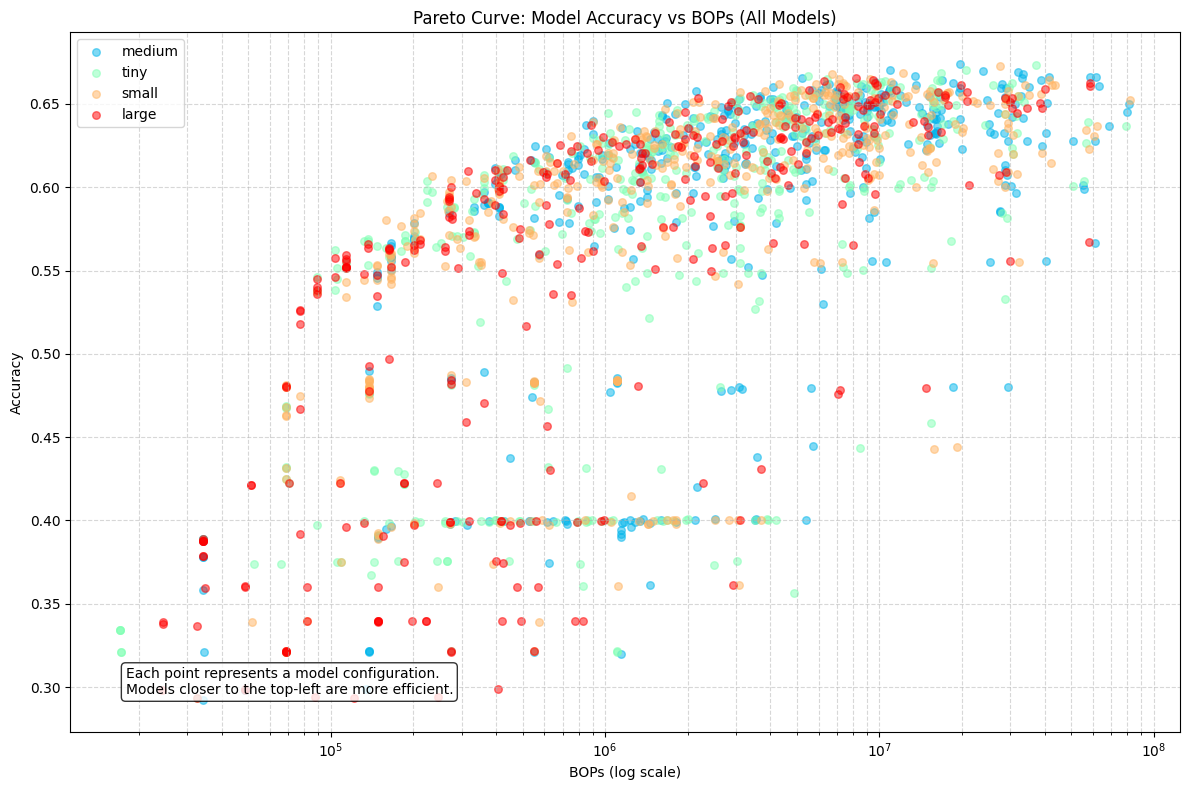

In [5]:
# Collect data
data = []
for model_type, file_path in model_files.items():
    all_models = get_all_models(model_type, file_path)
    data.extend(all_models)
    # print("len all models", len(all_models))
    # print("len data", len(data))
    # assert(False)
print("data example", data[0])
   


# Plotting
plt.figure(figsize=(12, 8))

model_types = set(item[0] for item in data)
colors = plt.cm.rainbow(np.linspace(0, 1, len(model_types)))
color_map = dict(zip(model_types, colors))

for model_type in model_types:
    if model_type == 'deepsets':
        continue
    model_data = [item for item in data if item[0] == model_type]
    x = [item[2] for item in model_data]  # BOPs
    y = [item[1] for item in model_data]  # Accuracy
    plt.scatter(x, y, c=[color_map[model_type]], label=model_type, s=30, alpha=0.5)

plt.xscale('log')  # Use log scale for BOPs
plt.xlabel('BOPs (log scale)')
plt.ylabel('Accuracy')
plt.title('Pareto Curve: Model Accuracy vs BOPs (All Models)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

# Add a text box explaining how to interpret the plot
plt.text(0.05, 0.05, 'Each point represents a model configuration.\n'
         'Models closer to the top-left are more efficient.',
         transform=plt.gca().transAxes, fontsize=10, 
         verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

data example ('large', 0.6645797805525284, 9443340.0)


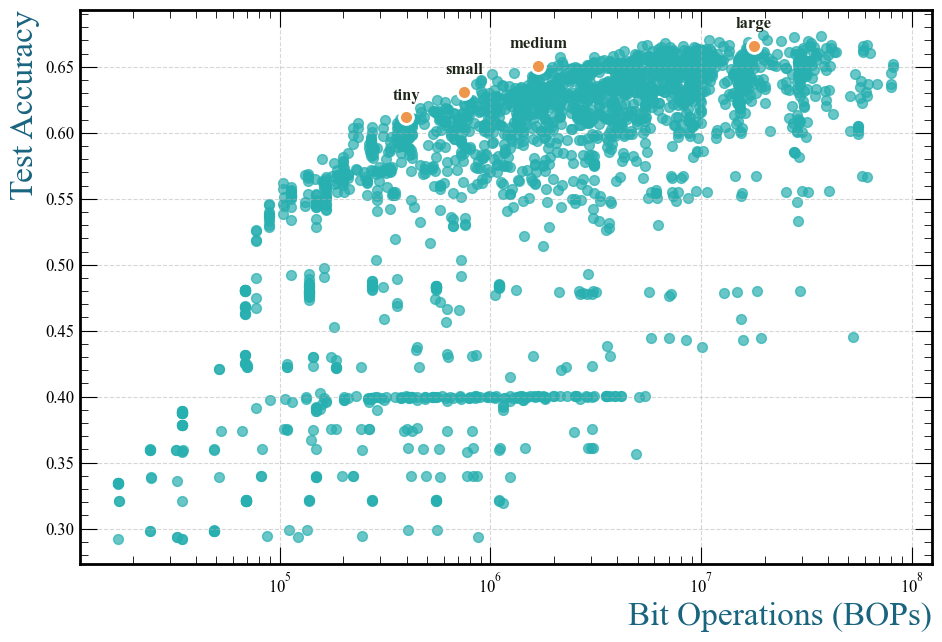

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import mplhep as hep
from matplotlib import font_manager

# Add the custom font
font_path = '/Users/dimademler/Downloads/Times_New_Roman.ttf'
font_manager.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Times New Roman'

# Create a font dictionary
font = {'family': 'Times New Roman',
        'weight': 'normal'}

plt.style.use(hep.style.ROOT)

# Collect data
data = []
for model_type, file_path in model_files.items():
    all_models = get_all_models(model_type, file_path)
    data.extend(all_models)
print("data example", data[0])

# Specific accuracies to highlight and their corresponding model types
highlight_accuracies = [0.611567992, 0.6306361314, 0.6506392925, 0.665486519]
model_types = ['tiny', 'small', 'medium', 'large']

# Plotting
plt.figure(figsize=(10, 7))

# Extract x and y values from all data points
x = [item[2] for item in data]  # BOPs
y = [item[1] for item in data]  # Accuracy

# Plot all points with the color #EE964B
plt.scatter(x, y, c='#28AFB0', s=50, alpha=0.7, label='All models')

# Highlight specific models and add labels
for accuracy, model_type in zip(highlight_accuracies, model_types):
    for item in data:
        if abs(item[1] - accuracy) < 0.0000001:  # Use a small threshold for float comparison
            plt.scatter(item[2], item[1], c='#EE964B', s=100, edgecolors='white', linewidth=2, zorder=5)
            plt.annotate(model_type, (item[2], item[1]), xytext=(0, 10), 
                         textcoords='offset points', ha='center', va='bottom',
                         fontsize=12, fontweight='bold', color='#1F271B', font=font)

plt.xscale('log')  # Use log scale for BOPs
plt.xlabel('Bit Operations (BOPs)', fontsize=24, **font, color='#19647E')
plt.ylabel('Test Accuracy', fontsize=24, **font, color='#19647E')
plt.grid(True, which="major", ls="--", alpha=0.5)

# Use a similar color scheme for other elements
plt.tick_params(axis='y', labelsize=12) 
plt.tick_params(axis='x', labelsize=12)
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#353535', '#6d597a', '#e56b6f', '#eaac8b'])

# Ensure tick labels are also in Times New Roman
plt.xticks(fontname='Times New Roman')
plt.yticks(fontname='Times New Roman')



plt.tight_layout()
plt.savefig('/Users/dimademler/Downloads/Oct1_Particle_Jet_Global_Search_Pareto_Front.pdf', dpi=300, bbox_inches='tight')
plt.show()

data example ('large', 0.6645797805525284, 9443340.0)


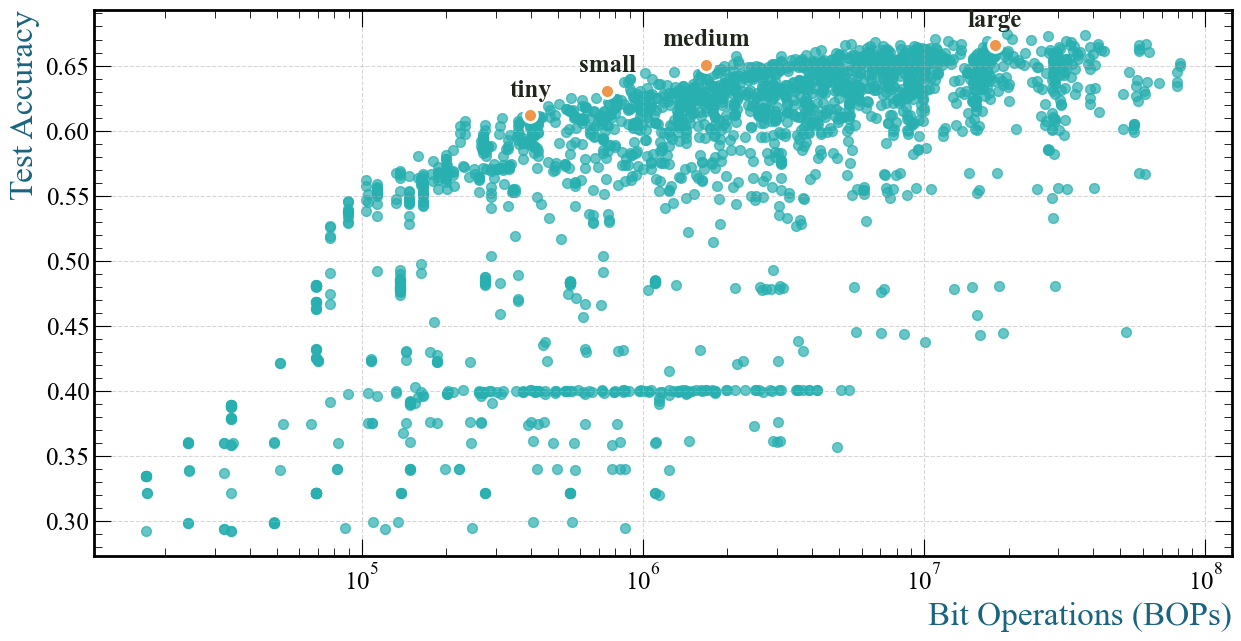

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import mplhep as hep
from matplotlib import font_manager

# Add the custom font
font_path = '/Users/dimademler/Downloads/Times_New_Roman.ttf'
font_manager.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Times New Roman'

# Create a font dictionary
font = {'family': 'Times New Roman',
        'weight': 'normal'}

plt.style.use(hep.style.ROOT)

# Collect data
data = []
for model_type, file_path in model_files.items():
    all_models = get_all_models(model_type, file_path)
    data.extend(all_models)
print("data example", data[0])

# Specific accuracies to highlight and their corresponding model types
highlight_accuracies = [0.611567992, 0.6306361314, 0.6506392925, 0.665486519]
model_types = ['tiny', 'small', 'medium', 'large']

# Plotting
plt.figure(figsize=(13, 7))

# Extract x and y values from all data points
x = [item[2] for item in data]  # BOPs
y = [item[1] for item in data]  # Accuracy

# Plot all points with the color #EE964B
plt.scatter(x, y, c='#28AFB0', s=50, alpha=0.7, label='All models')

# Highlight specific models and add labels
for accuracy, model_type in zip(highlight_accuracies, model_types):
    for item in data:
        if abs(item[1] - accuracy) < 0.0000001:  # Use a small threshold for float comparison
            plt.scatter(item[2], item[1], c='#EE964B', s=100, edgecolors='white', linewidth=2, zorder=5)
            plt.annotate(model_type, (item[2], item[1]), xytext=(0, 10), 
                         textcoords='offset points', ha='center', va='bottom',
                         fontsize=18, fontweight='bold', color='#1F271B', font=font)

plt.xscale('log')  # Use log scale for BOPs
plt.xlabel('Bit Operations (BOPs)', fontsize=24, **font, color='#19647E')
plt.ylabel('Test Accuracy', fontsize=24, **font, color='#19647E')
plt.grid(True, which="major", ls="--", alpha=0.5)

# Use a similar color scheme for other elements
plt.tick_params(axis='both', which='major', labelsize=18)

# plt.tick_params(axis='y', labelsize=20) 
# plt.tick_params(axis='x', labelsize=20)
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#353535', '#6d597a', '#e56b6f', '#eaac8b'])

# Ensure tick labels are also in Times New Roman
plt.xticks(fontname='Times New Roman')
plt.yticks(fontname='Times New Roman')



plt.tight_layout()
plt.savefig('/Users/dimademler/Downloads/Oct6_Particle_Jet_Global_Search_ParetoFront_poster.pdf', dpi=300, bbox_inches='tight')
plt.show()

data example ('large', 0.6645797805525284, 9443340.0)


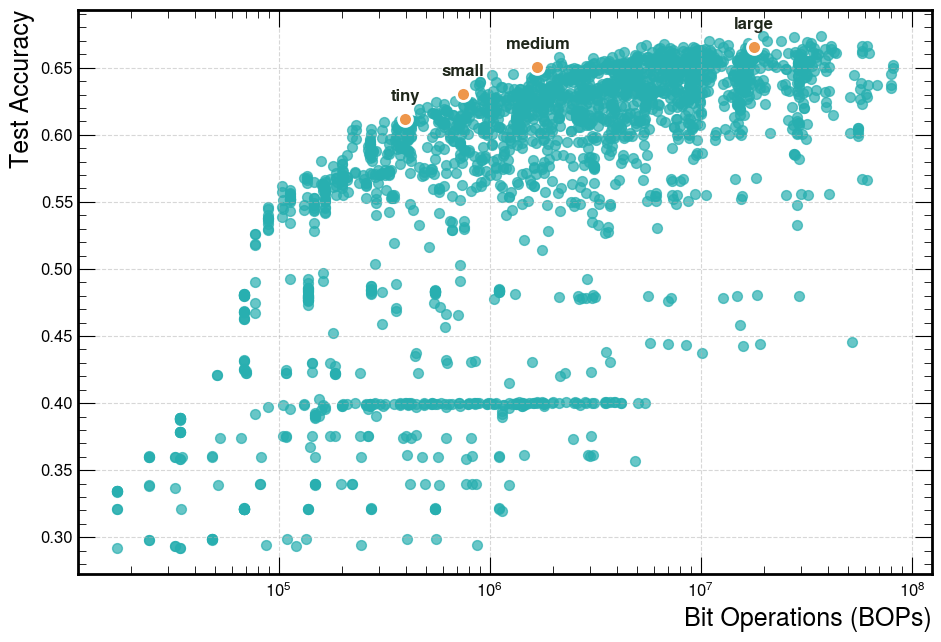

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import mplhep as hep
plt.style.use(hep.style.ROOT)


# Collect data
data = []
for model_type, file_path in model_files.items():
    all_models = get_all_models(model_type, file_path)
    data.extend(all_models)
print("data example", data[0])

# Specific accuracies to highlight and their corresponding model types
highlight_accuracies = [0.611567992, 0.6306361314, 0.6506392925, 0.665486519]
model_types = ['tiny', 'small', 'medium', 'large']

# Plotting
plt.figure(figsize=(10, 7))

# Extract x and y values from all data points
x = [item[2] for item in data]  # BOPs
y = [item[1] for item in data]  # Accuracy

# Plot all points with the color #EE964B
plt.scatter(x, y, c='#28AFB0', s=50, alpha=0.7, label='All models')

# Highlight specific models and add labels
for accuracy, model_type in zip(highlight_accuracies, model_types):
    for item in data:
        if abs(item[1] - accuracy) < 0.0000001:  # Use a small threshold for float comparison
            plt.scatter(item[2], item[1], c='#EE964B', s=100, edgecolors='white', linewidth=2, zorder=5)
            plt.annotate(model_type, (item[2], item[1]), xytext=(0, 10), 
                         textcoords='offset points', ha='center', va='bottom',
                         fontsize=12, fontweight='bold', color='#1F271B')

plt.xscale('log')  # Use log scale for BOPs
plt.xlabel('Bit Operations (BOPs)', fontsize=18)
plt.ylabel('Test Accuracy', fontsize=18)
# plt.title('Particle Jet Global Search Pareto Front', fontsize=16)
plt.grid(True, which="major", ls="--", alpha=0.5)

# Use a similar color scheme for other elements
plt.tick_params(axis='y', labelsize=12) 
plt.tick_params(axis='x', labelsize=12)
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#353535', '#6d597a', '#e56b6f', '#eaac8b'])

plt.tight_layout()
plt.savefig('Particle_Jet_Global_Search_Pareto_Front.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [8]:

def find_top_five_accuracies(file_path):
    accuracies = []
    
    with open(file_path, 'r') as file:
        for line in file:
            if line.startswith("Test Accuracy:"):
                match = re.search(r"Test Accuracy: (\d+\.\d+)", line)
                if match:
                    accuracy = float(match.group(1))
                    accuracies.append(accuracy)
    
    top_five = nlargest(5, accuracies)
    return top_five

# Set the file path here
file_path_large = "Large_architecture.txt"
file_path_medium = "Medium_architecture.txt"
file_path_small = "Small_architecture.txt"
file_path_tiny = "Tiny_architecture.txt"

def print_model_accuracy(file, name):
    try:
        top_accuracies = find_top_five_accuracies(file)
        print(f"Top five test accuracies for {name}:")
        for i, accuracy in enumerate(top_accuracies, 1):
            print(f"{i}. {accuracy:.4f}")
    except FileNotFoundError:
        print("File not found. Please check the file path and try again.")
    except Exception as e:
        print(f"An error occurred: {e}")

for file, name in [(file_path_large, "Large"), (file_path_medium, "Medium"), (file_path_small, "Small"), (file_path_tiny, "Tiny")]:
    print_model_accuracy(file, name)

# try:
#     top_accuracies = find_top_five_accuracies(file_path)
#     print("Top five test accuracies:")
#     for i, accuracy in enumerate(top_accuracies, 1):
#         print(f"{i}. {accuracy:.4f}")
# except FileNotFoundError:
#     print("File not found. Please check the file path and try again.")
# except Exception as e:
#     print(f"An error occurred: {e}")

File not found. Please check the file path and try again.
File not found. Please check the file path and try again.
File not found. Please check the file path and try again.
File not found. Please check the file path and try again.
